# MATH 210 Introduction to Mathematical Computing

**March 11, 2026**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Euler's Method

Write a function called `odeEuler` which takes function `f` (which represents a differential equation $y' = f(t,y)$), vector `t` of $t$ values, initial value `y0` (corresponds to `t[0]`), and returns a matrix where the first column are the $t$ values and second column are the $y$ values computed using Euler's method.

In [2]:
def odeEuler(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        y[n + 1] = y[n] + f(t[n],y[n])*(t[n + 1] - t[n])
    return np.column_stack([t,y])

Apply to $y' = y$, $y(0) = 1$, and compare to exact solution $y(t) = e^t$.

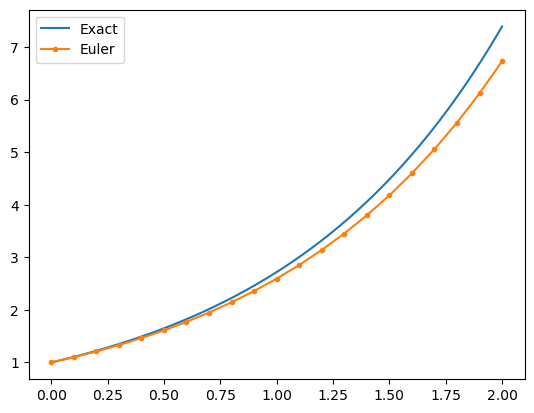

In [3]:
f = lambda t,y: y
t = np.linspace(0,2,21)
y0 = 1
result = odeEuler(f,t,y0)
T1 = result[:,0]
Y1 = result[:,1]

ts = np.linspace(0,2,200)
ys = np.exp(ts)
plt.plot(ts,ys,T1,Y1,'.-'), plt.legend(['Exact','Euler'])
plt.show()

## Heun's Method

Write a function called `odeHeun` which takes function `f` (which represents a differential equation $y' = f(t,y)$), vector `t` of $t$ values, initial value `y0` (corresponds to `t[0]`), and returns a matrix where the first column are the $t$ values and second column are the $y$ values computing using Heun's method.

In [4]:
def odeHeun(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        k1 = f(t[n],y[n])
        k2 = f(t[n] + h, y[n] + k1*h)
        y[n + 1] = y[n] + (k1 + k2)/2*h
    return np.column_stack([t,y])

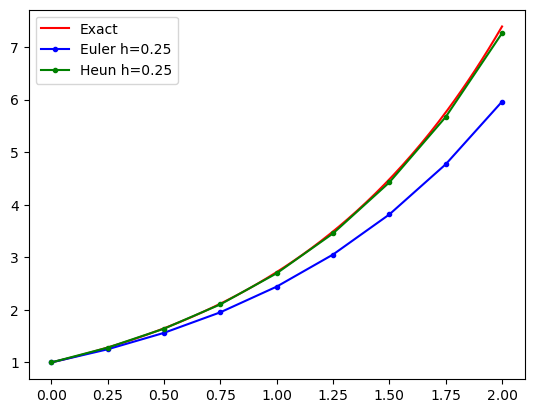

In [22]:
f = lambda t,y: y
t = np.linspace(0,2,9)
y0 = 1

result1 = odeEuler(f,t,y0)
T1 = result1[:,0]
Y1 = result1[:,1]

result2 = odeHeun(f,t,y0)
T2 = result2[:,0]
Y2 = result2[:,1]

ts = np.linspace(0,2,200)
ys = np.exp(ts)
plt.plot(ts,ys,'r',T1,Y1,'.-b',T2,Y2,'.-g'), plt.legend(['Exact','Euler h=0.25','Heun h=0.25'])
plt.show()